--- Running Unified Object-Oriented Pipeline (Horizon=3) ---

Processing Region: Lower Fraser Valley ...
  -> Training 10_Transformer_Wildfire...
      [Tuning] Using User-Defined Validation Set (2024) for Optuna...
      [Tuning] Best Params Found: {'d_model': 32, 'nhead': 4, 'num_layers': 3, 'lr': 0.0002839060271462693, 'dropout': 0.3125522775366053}
      [Tuning] Optimizing Threshold for High Recall (F2-Score)...
      [Tuning] Selected Threshold: 0.50 (F2 Score: 0.270)


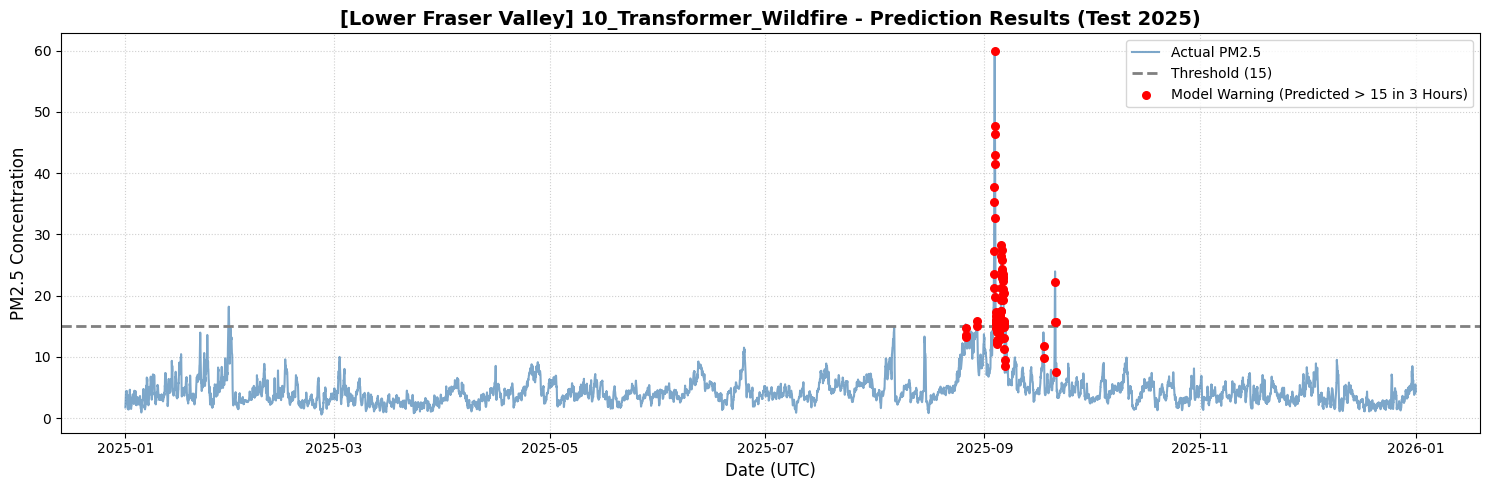


Processing Region: Southern Interior ...
  -> Training 10_Transformer_Wildfire...
      [Tuning] Using User-Defined Validation Set (2024) for Optuna...
      [Tuning] Best Params Found: {'d_model': 32, 'nhead': 2, 'num_layers': 1, 'lr': 0.0003199799988736205, 'dropout': 0.24199478735924715}
      [Tuning] Optimizing Threshold for High Recall (F2-Score)...
      [Tuning] Selected Threshold: 0.10 (F2 Score: 0.775)


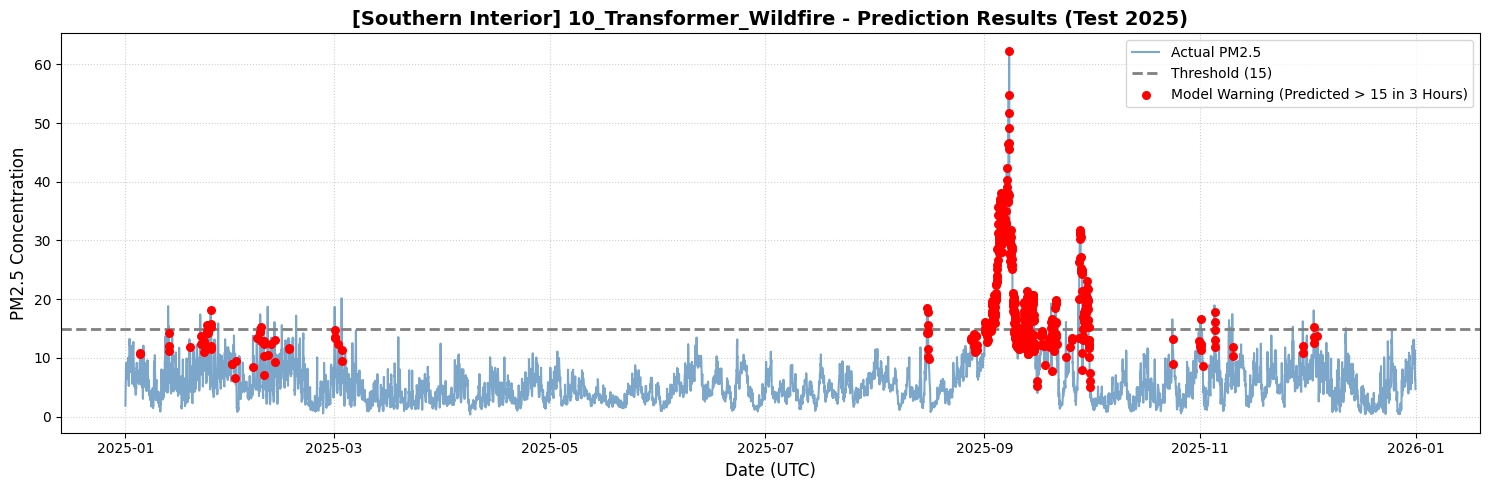


=== Final Classification Report ===


,,Probability_Threshold,Recall,Precision,Accuracy,F1
Region_Name,Model_Type,,,,,
Lower Fraser Valley,10_Transformer_Wildfire,0.5,0.705128,0.723684,0.994977,0.714286
Southern Interior,10_Transformer_Wildfire,0.1,0.836620,0.608607,0.971575,0.704626


In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
import warnings

warnings.filterwarnings('ignore')

current_dir = Path.cwd()
models_dir = current_dir / 'Models'
if str(models_dir) not in sys.path:
    sys.path.append(str(models_dir))

from Models.base_model import TARGET_COL, EXCEEDANCE_THRESHOLD, WILDFIRE_COLUMNS
from Models.GAM_GRACH import GAMGARCHModel          
from Models.lightboost import LightGBMModel         
from Models.catboost_model import CatBoostModel
# from Models.TFT_model import TFTModel
# from Models.PatchTST_model import PatchTSTModel
# from Models.DeepAR_model import DeepARModel
# from Models.NHITS_model import NHITSModel
from Models.LSTM_AE_model import AutoencoderLSTMModel 
from Models.Transformer_model import VanillaTransformerModel

if __name__ == "__main__":
    PROJECT_DIRECTORY = Path.cwd().parents[0]
    dataset_file_path = PROJECT_DIRECTORY / "Dataset" / "Outputs" / "CS2_model_input.csv"
    
    raw_input_dataframe = pd.read_csv(dataset_file_path)
    raw_input_dataframe['Datetime_UTC'] = pd.to_datetime(raw_input_dataframe['Datetime_UTC'])
    available_regions_list = raw_input_dataframe['Zone'].unique()
    all_results = []

    print("--- Running Unified Object-Oriented Pipeline (Horizon=3) ---")

    for region_name in available_regions_list:
        print(f"\nProcessing Region: {region_name} ...")
        regional_df = raw_input_dataframe[raw_input_dataframe['Zone'] == region_name].copy()
        regional_df = regional_df.set_index('Datetime_UTC').sort_index()
        if regional_df.index.tz is not None:
            regional_df.index = regional_df.index.tz_localize(None)
            
        train_data = regional_df[regional_df.index.year <= 2023].copy()
        val_data = regional_df[regional_df.index.year == 2024].copy()
        test_data = regional_df[regional_df.index.year == 2025].copy()
        
        if len(train_data) < 200: continue

        # 這裡可以自由打開你想測驗的模型！
        models_to_run = {
            # "1_GAM_Baseline": GAMGARCHModel(candidate_features=[]),
            # "3_LightGBM_Wildfire": LightGBMModel(candidate_features=WILDFIRE_COLUMNS),
            # "4_CatBoost_Wildfire": CatBoostModel(candidate_features=WILDFIRE_COLUMNS),
            # "5_TFT_Wildfire": TFTModel(candidate_features=WILDFIRE_COLUMNS),
            # "6_PatchTST_Wildfire": PatchTSTModel(candidate_features=WILDFIRE_COLUMNS),
            # "7_DeepAR_Wildfire": DeepARModel(candidate_features=WILDFIRE_COLUMNS),
            # "8_NHITS_Wildfire": NHITSModel(candidate_features=WILDFIRE_COLUMNS),
            # "9_LSTM_AE_Wildfire": AutoencoderLSTMModel(candidate_features=WILDFIRE_COLUMNS),
            "10_Transformer_Wildfire": VanillaTransformerModel(candidate_features=WILDFIRE_COLUMNS)
        }

        for model_name, model in models_to_run.items():
            print(f"  -> Training {model_name}...")
            
            # 🚀 根據模型類型，決定是否在訓練時傳入 Validation Set 供 Optuna 內部調參使用
            if isinstance(model, VanillaTransformerModel):
                model.fit(train_data, val_df=val_data)
            else:
                model.fit(train_data)
            
            # 訓練完畢後，所有模型統一使用 2024 年資料來尋找最佳判定門檻 (Threshold Tuning)
            model.tune_threshold(val_data)
            
            test_preds = model.predict(test_data)
            processed_test = model.preprocess(test_data)
            actuals = (processed_test[TARGET_COL] > EXCEEDANCE_THRESHOLD).astype(int)
            
            all_results.append({
                "Region_Name": region_name,
                "Model_Type": model_name,
                "Probability_Threshold": round(model.alert_probability_threshold, 2),
                "Recall": float(recall_score(actuals, test_preds, zero_division=0)),
                "Precision": float(precision_score(actuals, test_preds, zero_division=0)),
                "Accuracy": float(accuracy_score(actuals, test_preds)),
                "F1": float(f1_score(actuals, test_preds, zero_division=0))
            })

            # 視覺化預測結果
            plt.figure(figsize=(15, 5))
            test_dates = processed_test.index
            actual_pm25 = processed_test[TARGET_COL].values
            
            plt.plot(test_dates, actual_pm25, label='Actual PM2.5', color='steelblue', alpha=0.7, linewidth=1.5)
            plt.axhline(EXCEEDANCE_THRESHOLD, color='gray', linestyle='--', linewidth=2, label=f'Threshold ({EXCEEDANCE_THRESHOLD})')
            
            predicted_alert_indices = np.where(test_preds == 1)[0]
            plt.scatter(
                test_dates[predicted_alert_indices], actual_pm25[predicted_alert_indices], 
                color='red', s=30, zorder=5, label='Model Warning (Predicted > 15 in 3 Hours)'
            )
            
            plt.title(f'[{region_name}] {model_name} - Prediction Results (Test 2025)', fontsize=14, fontweight='bold')
            plt.xlabel('Date (UTC)', fontsize=12)
            plt.ylabel('PM2.5 Concentration', fontsize=12)
            plt.legend(loc='upper right')
            plt.grid(True, linestyle=':', alpha=0.6)
            plt.tight_layout()
            plt.show()

    print("\n=== Final Classification Report ===")
    results_df = pd.DataFrame(all_results)
    if not results_df.empty:
        results_df = results_df.set_index(["Region_Name", "Model_Type"]).sort_index()
        try:
            display(results_df) 
        except NameError:
            print(results_df) 
    else:
        print("No results generated.")